In [1]:
from MDAnalysis.analysis.rdf import InterRDF
import MDAnalysis as mda
from MDAnalysis.analysis import rdf
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
## Convert ase trajectory
# ! rm ../output/wat_mace_small/wat_300_npt.pdb
# ! ase convert ../output/wat_mace_small/wat_300_npt.traj ../output/wat_mace_small/wat_300_npt.pdb
# ! ase convert ../output/2l_wat_grace_small_a_wpS/wat_300_npt.traj ../output/2l_wat_grace_small_a_wpS/wat_300_npt.pdb
# ! ase convert ../output/2l_wat_grace_medium_a_wpS/wat_300_npt.traj ../output/2l_wat_grace_medium_a_wpS/wat_300_npt.pdb
# ! ase convert ../output/1l_wat_grace_small_a_wpS/wat_300_npt.traj ../output/1l_wat_grace_small_a_wpS/wat_300_npt.pdb
# ! ase convert ../output/1l_wat_grace_medium_a_wpS/wat_300_npt.traj ../output/1l_wat_grace_medium_a_wpS/wat_300_npt.pdb
! ase convert ../output/2l_wat_grace_small_b_off/wat_300_npt.traj ../output/2l_wat_grace_small_b_off/wat_300_npt.pdb


In [3]:
traj = {
    # "grace small 1l": "../output/1l_wat_grace_small_a_wpS/wat_300_npt.pdb",
    # "grace small 2l": "../output/2l_wat_grace_small_a_wpS/wat_300_npt.pdb",
    "grace small 2l off": "../output/2l_wat_grace_small_b_off/wat_300_npt.pdb",
    # "grace medium 1l": "../output/1l_wat_grace_medium_a_wpS/wat_300_npt.pdb",
    # "grace medium 2l": "../output/2l_wat_grace_medium_a_wpS/wat_300_npt.pdb",
    "mace small": "../output/wat_mace_small/wat_300_npt.pdb",
}


model_rdf = dict()

for model, path in traj.items():

    u = mda.Universe(path)

    irdf2 = dict()

    oxygen = u.select_atoms("name O*")
    hydrogen = u.select_atoms("name H*")

    for i, combination in enumerate(["o-o", "o-h", "h-h"]):
        if combination == "o-o":
            group1 = oxygen
            group2 = oxygen
            exclusion_block = (1, 1)
        elif combination == "o-h":
            group1 = oxygen
            group2 = hydrogen
            exclusion_block = (1, 2)
        elif combination == "h-h":
            group1 = hydrogen
            group2 = hydrogen
            exclusion_block = (2, 2)

        irdf2[combination] = InterRDF(
            group1,
            group2,
            nbins=75,  # default
            range=(0.0, 12.0),  # distance in angstroms
            exclusion_block=exclusion_block,  # exclude intramolecular pairs
        )
        irdf2[combination].run(step=100)

    model_rdf[path] = irdf2

plt.tight_layout()
plt.show()

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


<Figure size 640x480 with 0 Axes>

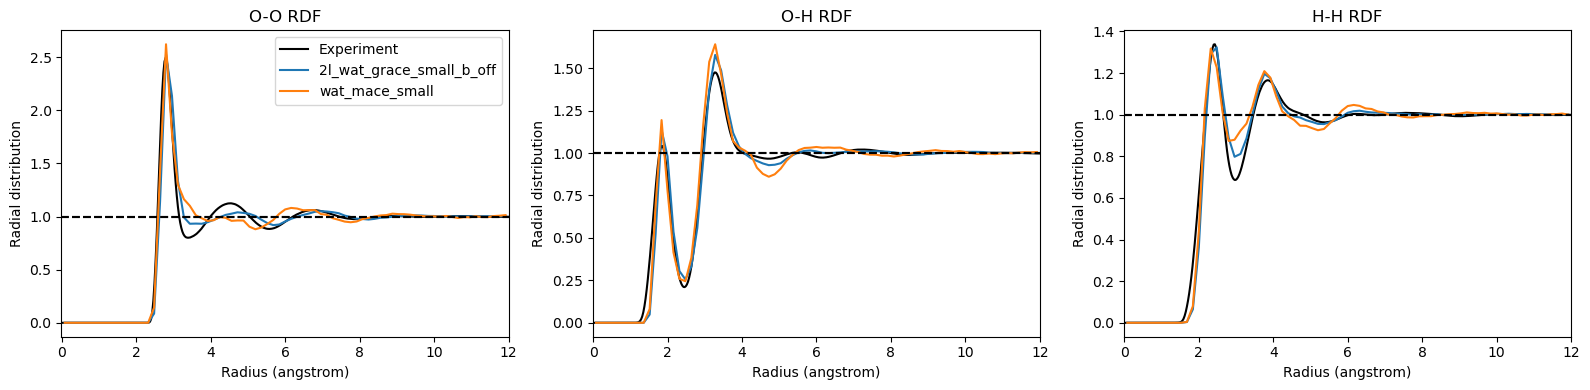

In [4]:
# water data ----------------------------------

exp_water = pd.read_csv("../data/exp_data/exp_water.dat", delimiter="\t")
r_A = exp_water[" r[A] "]
rdf_exp_OO = exp_water["O–O "]
rdf_exp_Oh = exp_water["O–H "]
rdf_exp_hh = exp_water["H–H "]
xlim_lower, xlim_upper = -0.2, 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(r_A, rdf_exp_OO, label="Experiment", color="black")
axes[1].plot(r_A, rdf_exp_Oh, label="Experiment", color="black")
axes[2].plot(r_A, rdf_exp_hh, label="Experiment", color="black")


for model, path in traj.items():
    rdf = model_rdf[path]
    for i, combination in enumerate(["o-o", "o-h", "h-h"]):

        axes[i].plot(
            rdf[combination].results.bins,
            rdf[combination].results.rdf,
            label=path.split("/")[2],
        )
        axes[i].axhline(y=1, color="k", linestyle="--")
        axes[i].set_xlabel("Radius (angstrom)")
        axes[i].set_ylabel("Radial distribution")
        axes[i].set_title(f"{combination.upper()} RDF")
        axes[i].set_xlim(-0.01, 12)
        axes[0].legend()

plt.tight_layout()
# plt.savefig("waterbox_rdf_comparison_exp.png", dpi=300)
plt.show()